# Pointing Corrections

Demonstration of how `heap.events` gives every telescope's images camera coordinates relative to one pointing for stereo reconstruction, and of
`events.pointing_corrections` (see `configs/crab.yaml`).

Each image's camera coordinates (`x_c`, `y_c`, deg) are relative to its own telescope's pointing. Before images from different
telescopes can be intersected, `load_camera_frame()`:
1. subtracts the **pointing correction**: that camera's offset from its **own** mount's pointing, per night, telescope and flip side
   (after postflip images are rotated 180 deg to the preflip orientation)
2. changes the origin of its camera coordinates from its own mount's pointing (`mount_pointings()`, from hk) to its run's
   **array pointing**, the mean of the telescopes' mount pointings in that run (`change_origin()`, `mean_pointings()`)

A pointing correction $(dx, dy)$ in deg is where a sky position **appears** in the camera minus where it **should** appear from that
telescope's mount pointing (`heap.significance.make_wcs()`), with +x east and +y south. For example, if the mount points at the
Crab, it should be at (0, 0); if it appears at (1, 1), 1 deg east and 1 deg south, the correction is (1, 1). In a wobble N run
the Crab should be at (0, 0.5) instead. Only the centroid moves: `phi`, `length` and `width` don't change.

We use toy images with known offsets, so we can check that everything is put back.

## Imports

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import astropy.units as u

from heap import events as ev
from heap import toy_events as toy
from heap.reconstruction import reconstruct_directions
from heap.significance import make_wcs
from heap.sources import SOURCES

## Toy Data

In [2]:
DATE = "toy"
SOURCE = SOURCES["Crab"]
WOBBLE = toy.wobble_pointings(SOURCE, 0.5, directions=("N",))["N"] # where the mounts are aimed, both runs
TELESCOPES = ["Winter", "Fern", "Heli", "Gattini"]
N_SHOWERS = 500 # per run

One preflip and one postflip run. Flip sides and runs only come from the run folders' start times (`heap.events.flip_side_of()`,
`run_of()`), so here they are just names, with no data in them.

In [3]:
RUN_STARTS = {"preflip": "2026-09-17T06:00:00", "postflip": "2026-09-17T09:00:00"} # UTC
RUNS = {side: [Path(f"obs_Crab.start_{start}Z.runtype_sci-obs.pffd")] for side, start in RUN_STARTS.items()}
RUN_NAMES = {side: run_dirs[0].name for side, run_dirs in RUNS.items()}

Each telescope's mount pointing (what `mount_pointings()` reads from hk), as (east, north) offsets in deg from where they were aimed,
and each camera's offset from its own mount, in the config's format `{(date, telescope, flip_side): (dx, dy)}` (what
`heap.config.load_analysis_config()` turns the YAML into):

In [4]:
MOUNT_ERRORS = {
    "Winter": {"preflip": (0.00, 0.00), "postflip": (0.05, -0.05)},
    "Fern": {"preflip": (0.15, -0.05), "postflip": (0.10, 0.00)},
    "Heli": {"preflip": (-0.10, 0.10), "postflip": (-0.15, 0.05)},
    "Gattini": {"preflip": (0.05, -0.15), "postflip": (0.00, -0.10)},
}
MOUNTS = {
    tel: {RUN_NAMES[side]: WOBBLE.spherical_offsets_by(east*u.deg, north*u.deg) for side, (east, north) in sides.items()}
    for tel, sides in MOUNT_ERRORS.items()
}

OFFSETS = {
    (DATE, "Winter", "preflip"): (0.10, 0.05),
    (DATE, "Fern", "preflip"): (0.25, -0.15),
    (DATE, "Fern", "postflip"): (-0.10, 0.20),
    (DATE, "Heli", "preflip"): (-0.30, 0.10),
    (DATE, "Heli", "postflip"): (0.15, 0.25),
    (DATE, "Gattini", "preflip"): (0.05, 0.30),
    (DATE, "Gattini", "postflip"): (0.20, -0.10),
}

Each run's array pointing is the mean of its mount pointings (`mean_pointings()`), and the source is 0.5 deg south of it
(camera coordinates: deg from the array pointing, +x east, +y south):

In [5]:
ARRAY_POINTINGS = ev.mean_pointings(MOUNTS)
for side, run in RUN_NAMES.items():
    x, y = make_wcs(ARRAY_POINTINGS[run]).wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1)
    print(f"{side:8s}: source at x = {x:.3f}, y = {y:.3f} deg")

preflip : source at x = -0.025, y = 0.475 deg
postflip: source at x = -0.000, y = 0.475 deg


`simulate_images()` makes toy gamma-ray showers from the source, each seen by every telescope. Each image has its centroid 0.5-2 deg from the source (in camera coordinates relative to that telescope's mount pointing), in a random direction, and its axis pointing back
at the source (to within a few deg). Then, like a real camera:
1. the image is shifted by that camera's offset from its mount, for the run's flip side
2. postflip images are rotated 180 deg (that's what the camera sees after the flip; `load_camera_frame()` rotates them back)

The images are written as one `<source_slug>.npz` per telescope, like `heap.process_dataset.process_dataset()` does, so
`load_camera_frame()` reads them as it would real data. `miss`, `distance` and `alpha` aren't used here.

In [6]:
def simulate_images(rng):
    images = {tel: [] for tel in TELESCOPES}
    for side, start in RUN_STARTS.items():
        timestamps = np.sort(pd.Timestamp(start, tz="UTC").timestamp() + rng.uniform(0, 3600, N_SHOWERS))
        for tel in TELESCOPES:
            n = N_SHOWERS
            source_xy = make_wcs(MOUNTS[tel][RUN_NAMES[side]]).wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1)
            r = rng.uniform(0.5, 2.0, n)
            psi = rng.uniform(0, 360, n)
            x = source_xy[0] + r*np.cos(np.deg2rad(psi))
            y = source_xy[1] + r*np.sin(np.deg2rad(psi))
            phi = psi + rng.normal(0, 3, n) # image axis through the source

            dx, dy = OFFSETS.get((DATE, tel, side), (0, 0))
            x, y = x + dx, y + dy
            if side == "postflip":
                x, y, phi = -x, -y, phi + 180

            images[tel].append(pd.DataFrame({
                "Timestamp": timestamps, "x_c": x, "y_c": y, "phi": phi % 360,
                "size": rng.lognormal(np.log(500), 0.5, n), "N_pix": 10,
                "length": rng.uniform(0.4, 0.8, n), "width": rng.uniform(0.15, 0.3, n),
                "miss": np.nan, "distance": np.nan, "alpha": np.nan,
            }))

    tmp = Path(tempfile.mkdtemp())
    paths = {}
    for tel, parts in images.items():
        df = pd.concat(parts, ignore_index=True)
        df.insert(0, "Event", np.arange(len(df)))
        paths[tel] = tmp / f"{tel}.npz"
        np.savez(paths[tel], **{col: df[col].to_numpy() for col in df})
    return paths


npz_paths = simulate_images(np.random.default_rng(0))

## Loading

`load_camera_frame()` three ways:
- **as recorded**: each telescope's images as its camera recorded them, measured from its own camera center
- **pointing correction**: pointing corrections subtracted, so measured from each telescope's own mount pointing
- **pointing correction + change of origin**: also with the origin changed to the run's array pointing (`pointings` and `array_pointings`), as
  `load_camera_frames()` does

It takes one telescope's `{flip_side: (dx, dy)}`; `load_camera_frames()` picks those out of the config's dict for each night and
telescope, as below.

In [7]:
def load(corrections, change_origin):
    loaded = {}
    for tel in TELESCOPES:
        tel_corrections = {side: offset for (d, t, side), offset in corrections.items() if d == DATE and t == tel}
        loaded[tel] = ev.load_camera_frame(
            npz_paths[tel], tel, RUNS, rotate_postflip=True, pointing_corrections=tel_corrections,
            pointings=MOUNTS[tel] if change_origin else None, array_pointings=ARRAY_POINTINGS if change_origin else None,
        )
    return loaded


images = {
    "as recorded": load({}, change_origin=False),
    "pointing correction": load(OFFSETS, change_origin=False),
    "pointing correction + change of origin": load(OFFSETS, change_origin=True),
}

`x_shift`, `y_shift` are how far each centroid moved from its position in the (rotated) camera image. With the pointing correction only,
that's minus the config's offset, for each telescope and flip side (postflip in the rotated orientation). Changing the origin adds the
telescope's mount pointing's offset from the run's array pointing:

In [8]:
shifts = []
for label in ["pointing correction", "pointing correction + change of origin"]:
    df = pd.concat(images[label].values())
    shifts.append(df.groupby(["Telescope", "FlipSide"])[["x_shift", "y_shift"]].mean().round(3).add_prefix(f"{label}: "))
shift = pd.concat(shifts, axis=1)
shift["config (dx, dy)"] = [OFFSETS.get((DATE, tel, side), (0, 0)) for tel, side in shift.index]
shift

pointing correction: x_shift  \
Telescope FlipSide                                 
Fern      postflip                          0.10   
          preflip                          -0.25   
Gattini   postflip                         -0.20   
          preflip                          -0.05   
Heli      postflip                         -0.15   
          preflip                           0.30   
Winter    postflip                          0.00   
          preflip                          -0.10   

                    pointing correction: y_shift  \
Telescope FlipSide                                 
Fern      postflip                         -0.20   
          preflip                           0.15   
Gattini   postflip                          0.10   
          preflip                          -0.30   
Heli      postflip                         -0.25   
          preflip                          -0.10   
Winter    postflip                          0.00   
          preflip                          -0.05   

                    pointing correction + change of origin: x_shift  \
Telescope FlipSide                                                    
Fern      postflip                                            0.200   
          preflip                                            -0.125   
Gattini   postflip                                           -0.200   
          preflip                                            -0.025   
Heli      postflip                                           -0.301   
          preflip                                             0.174   
Winter    postflip                                            0.050   
          preflip                                            -0.125   

                    pointing correction + change of origin: y_shift  \
Telescope FlipSide                                                    
Fern      postflip                                           -0.225   
          preflip                                             0.175   
Gattini   postflip                                            0.175   
          preflip                                            -0.175   
Heli      postflip                                           -0.325   
          preflip                                            -0.225   
Winter    postflip                                            0.025   
          preflip                                            -0.075   

                   config (dx, dy)  
Telescope FlipSide                  
Fern      postflip     (-0.1, 0.2)  
          preflip    (0.25, -0.15)  
Gattini   postflip     (0.2, -0.1)  
          preflip      (0.05, 0.3)  
Heli      postflip    (0.15, 0.25)  
          preflip      (-0.3, 0.1)  
Winter    postflip          (0, 0)  
          preflip      (0.1, 0.05)

In [9]:
for tel in TELESCOPES:
    a, b = images["as recorded"][tel], images["pointing correction"][tel]
    assert (a[["phi", "length", "width", "size"]] == b[["phi", "length", "width", "size"]]).all().all()

Every telescope sees every toy shower, so an image's `ImageIndex` is its shower number, and we use it as `Event` (on real data,
`heap.events.build_events()` matches images into events by time):

In [10]:
def as_events(loaded):
    e = pd.concat(loaded.values(), ignore_index=True)
    e.insert(0, "Event", e.ImageIndex)
    e.insert(1, "Date", DATE) # build_array_events() adds Date
    return e


events = {label: as_events(loaded) for label, loaded in images.items()}

## One Shower

Each telescope's Hillas ellipse and image axis for one preflip and one postflip shower, relative to the run's array pointing (east
left, north up). As recorded, each axis passes through the source shifted by that camera's offset and its mount's offset from the array pointing, so the
axes miss each other. With the pointing correction only, the mounts' offsets are left. With the change of origin too, they cross near the source: like real
images, each toy image's axis is off by a few deg (`simulate_images()`), so an axis far from the source can miss it by a few tenths of a deg.

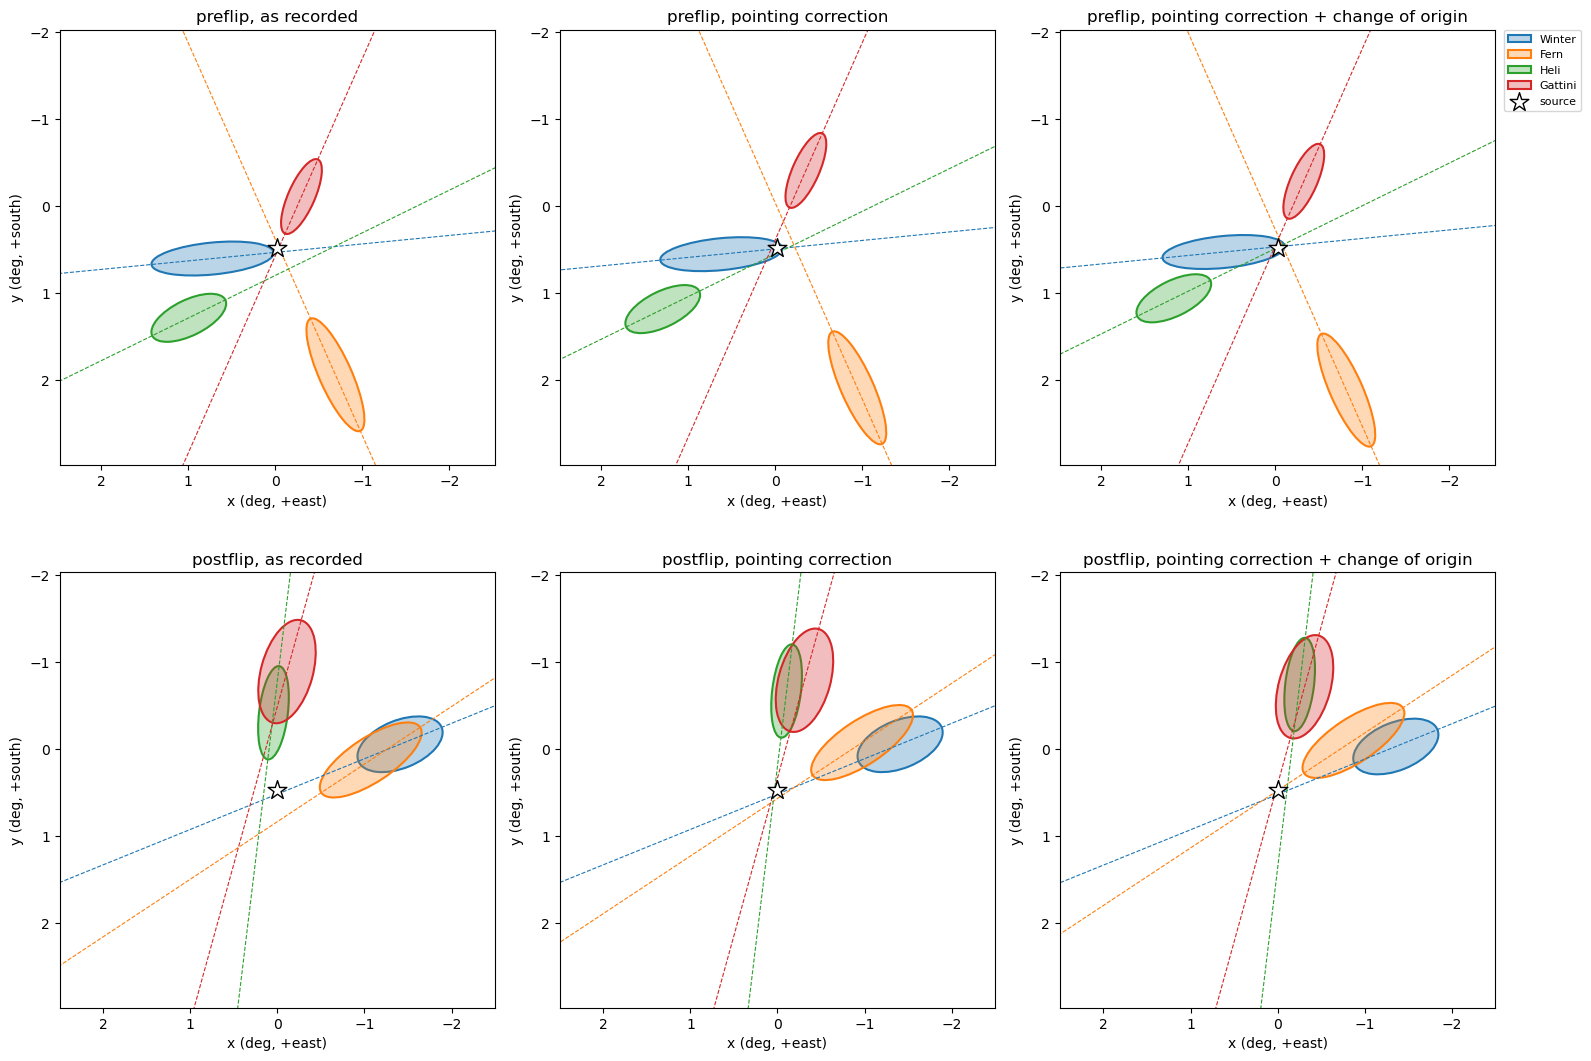

In [11]:
COLORS = {"Winter": "tab:blue", "Fern": "tab:orange", "Heli": "tab:green", "Gattini": "tab:red"}


def source_xy(run):
    return np.array(make_wcs(ARRAY_POINTINGS[run]).wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1))


def plot_shower(ax, event, title):
    for _, tel in event.iterrows():
        ev.draw_hillas(ax, tel, COLORS[tel.Telescope], fill_alpha=0.3)
    xy = source_xy(event.Run.iloc[0])
    ax.scatter(*xy, marker="*", facecolor="white", edgecolor="k", s=200, zorder=3, label="source")
    ax.set_xlim(xy[0] + 2.5, xy[0] - 2.5) # +x is east and +y south: reversed for east left, north up
    ax.set_ylim(xy[1] + 2.5, xy[1] - 2.5)
    ax.set_aspect("equal")
    ax.set(xlabel="x (deg, +east)", ylabel="y (deg, +south)", title=title)


fig, axs = plt.subplots(2, 3, figsize=(16, 11))
for row, side in zip(axs, ["preflip", "postflip"]):
    e = events["pointing correction + change of origin"]
    event = e[e.FlipSide == side].Event.iloc[0]
    for ax, (label, e) in zip(row, events.items()):
        plot_shower(ax, e[e.Event == event], f"{side}, {label}")
legend = {label: h for ax in axs[:, -1] for h, label in zip(*ax.get_legend_handles_labels())} # every telescope, from both rows
axs[0, -1].legend(legend.values(), legend.keys(), fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()

## Reconstruction

`heap.reconstruction.reconstruct_directions()` on every event, then each one's distance $\theta$ from the source.

In [12]:
def reconstruct(e):
    directions = reconstruct_directions(e)
    directions["FlipSide"] = directions.Event.map(e.groupby("Event").FlipSide.first())
    xy = np.array([source_xy(run) for run in directions.Run])
    directions["theta"] = np.hypot(directions.Xoffset - xy[:, 0], directions.Yoffset - xy[:, 1])
    return directions


directions = {label: reconstruct(e) for label, e in events.items()}

as recorded                            preflip : median offset from the source (+0.025, +0.077) deg, 68% containment 0.215 deg
as recorded                            postflip: median offset from the source (+0.080, +0.093) deg, 68% containment 0.286 deg
pointing correction                    preflip : median offset from the source (+0.006, -0.002) deg, 68% containment 0.149 deg
pointing correction                    postflip: median offset from the source (+0.009, +0.002) deg, 68% containment 0.128 deg
pointing correction + change of origin preflip : median offset from the source (+0.002, +0.000) deg, 68% containment 0.083 deg
pointing correction + change of origin postflip: median offset from the source (+0.006, +0.001) deg, 68% containment 0.086 deg


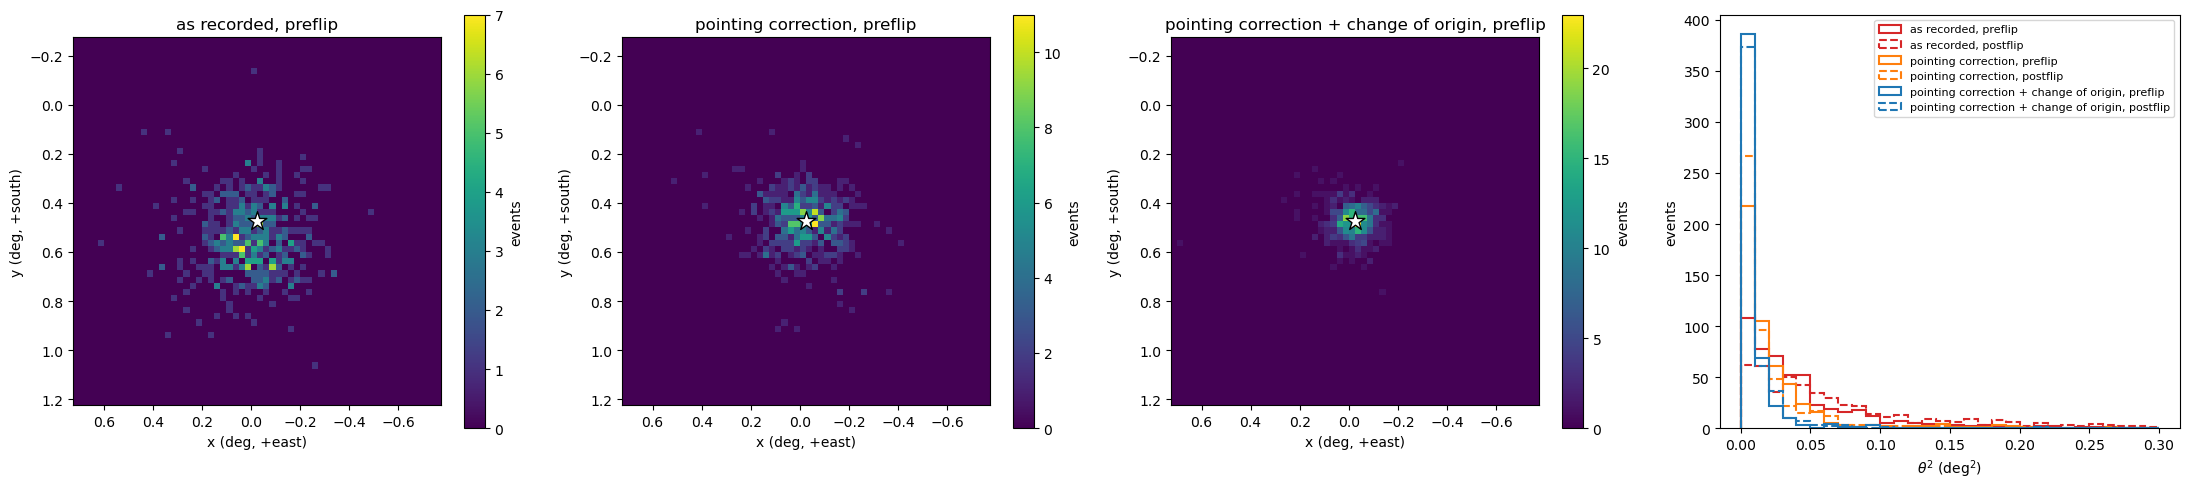

In [13]:
RANGE = 0.75 # deg from the source
fig, axs = plt.subplots(1, 4, figsize=(22, 5))
for ax, (label, d) in zip(axs, directions.items()):
    d = d[d.FlipSide == "preflip"] # one run, so one source position
    xy = source_xy(RUN_NAMES["preflip"])
    h = ax.hist2d(d.Xoffset, d.Yoffset, bins=60, range=[[xy[0] - RANGE, xy[0] + RANGE], [xy[1] - RANGE, xy[1] + RANGE]], cmap="viridis")
    ax.scatter(*xy, marker="*", facecolor="white", edgecolor="k", s=200)
    ax.set_xlim(xy[0] + RANGE, xy[0] - RANGE)
    ax.set_ylim(xy[1] + RANGE, xy[1] - RANGE)
    ax.set_aspect("equal")
    ax.set(xlabel="x (deg, +east)", ylabel="y (deg, +south)", title=f"{label}, preflip")
    fig.colorbar(h[3], ax=ax, label="events")

bins = np.linspace(0, 0.3, 31)
for (label, d), color in zip(directions.items(), ["tab:red", "tab:orange", "tab:blue"]):
    for side, ls in [("preflip", "-"), ("postflip", "--")]:
        axs[3].hist(d[d.FlipSide == side].theta**2, bins=bins, histtype="step", ls=ls, lw=1.5, color=color, label=f"{label}, {side}")
axs[3].set(xlabel=r"$\theta^2$ (deg$^2$)", ylabel="events")
axs[3].legend(fontsize=8)
plt.tight_layout()

for label, d in directions.items():
    for side, g in d.groupby("FlipSide", sort=False):
        print(f"{label:38s} {side:8s}: median offset from the source ({g.Xoffset.median() - source_xy(RUN_NAMES[side])[0]:+.3f}, "
              f"{g.Yoffset.median() - source_xy(RUN_NAMES[side])[1]:+.3f}) deg, 68% containment {g.theta.quantile(0.68):.3f} deg")

Only with both steps are the reconstructed directions back on the source, with only the spread from the image axes' few-deg scatter.

A shift shared by every image would leave the axes crossing at one point, just not the source: it moves the whole map rather than
blurring it. So the array pointing doesn't need to be any particular telescope's pointing, and the mean of the mounts is one choice;
what matters is that each image's origin is changed from its own mount's pointing.

## Postflip Sign

`load_camera_frame()` rotates postflip images 180 deg first, then subtracts the postflip offset **as given**: it does **not**
rotate the offset. So the postflip offset in the config must already be in rotated (preflip-orientation) coordinates, either:
- measured on rotated images, or
- measured on **raw** postflip images (e.g. star positions in pedvar maps, which aren't rotated) and **negated by you**

The code can't tell which, and doesn't check. Entering a raw measurement without negating it doubles the postflip error instead
of removing it:

In [14]:
raw_postflip = {key: ((-dx, -dy) if key[2] == "postflip" else (dx, dy)) for key, (dx, dy) in OFFSETS.items()}
d = reconstruct(as_events(load(raw_postflip, change_origin=True)))
for side, g in d.groupby("FlipSide", sort=False):
    print(f"{side:8s}: 68% containment {g.theta.quantile(0.68):.3f} deg")

preflip : 68% containment 0.083 deg
postflip: 68% containment 0.429 deg


## Summary

- `pointing_corrections[(date, telescope, flip_side)] = (dx, dy)`: where a sky position appears in that camera minus where its own
  mount's pointing puts it, in deg; subtracted from `x_c`, `y_c` in `load_camera_frame()`, so only centroids move
- postflip offsets must already be in rotated (preflip-orientation) coordinates; the code doesn't rotate them. Negate offsets
  measured on raw postflip images yourself
- each image's origin is then changed from its own mount's pointing to its run's array pointing, the mean of the mount pointings
  (`mean_pointings()`), so events are reconstructed the same way whichever telescopes saw them